# Simulación de circuito cuántico con Guppy

Circuito cuántico simple:
- Dos qubits
- Hadamard
- CNOT
- Medición
- Simulación con emulador


In [1]:
from guppylang import guppy
from guppylang.std.builtins import result
from guppylang.std.quantum import cx, h, measure, qubit, x

import matplotlib.pyplot as plt
import numpy as np


In [2]:
@guppy
def simple_circuit() -> qubit:
    q1, q2 = qubit(), qubit()

    h(q1)
    cx(q1, q2)

    outcome = measure(q1)
    result("q1", outcome)

    if outcome:
        x(q2)

    return q2


In [3]:
simple_circuit.check()


In [4]:
@guppy
def evaluate() -> None:
    q = simple_circuit()
    result("q2", measure(q))


In [5]:
shots = (
    evaluate
    .emulator(n_qubits=2)
    .with_seed(1)
    .with_shots(10000)
    .run()
)


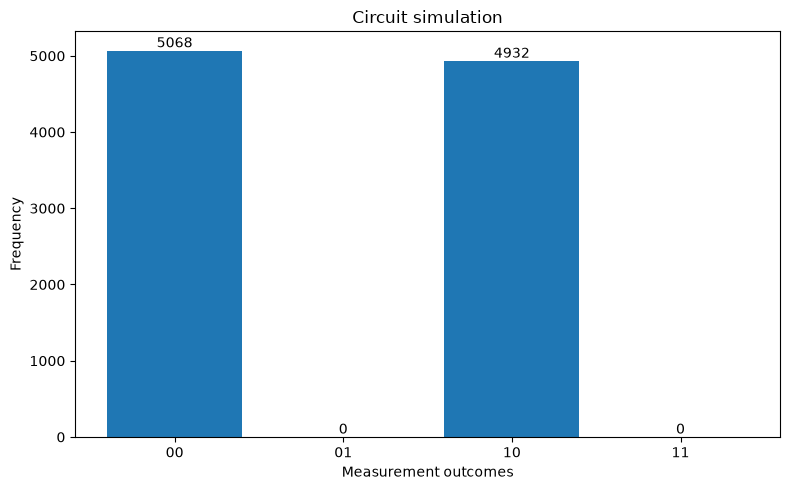

In [7]:
fig, ax = plt.subplots(figsize=(8,5))

possible_outcomes = ["00", "01", "10", "11"]

idx = np.arange(len(possible_outcomes))

counts = [
    len([
        shot for shot in shots
        if str(shot.as_dict()["q1"]) + str(shot.as_dict()["q2"]) == o
    ])
    for o in possible_outcomes
]

bars = ax.bar(idx, counts)

ax.bar_label(bars, labels=counts)

ax.set_title("Circuit simulation")
ax.set_xlabel("Measurement outcomes")
ax.set_ylabel("Frequency")

ax.set_xticks(idx)
ax.set_xticklabels(possible_outcomes)

plt.tight_layout()

plt.savefig(
    "../figures/figura.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
